In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def conv2d_single_channel(input_map, kernel, stride=1, padding=0):
    if padding > 0:
        input_map = np.pad(input_map, pad_width=padding, mode='constant', constant_values=0)
    k = kernel.shape[0]
    out_h = (input_map.shape[0] - k) // stride + 1
    out_w = (input_map.shape[1] - k) // stride + 1
    out = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            patch = input_map[i*stride:i*stride+k, j*stride:j*stride+k]
            out[i, j] = np.sum(patch * kernel)
    return out

In [5]:
def verify_formula(in_size, kernel_size, stride, padding):
    return (in_size + 2*padding - kernel_size) // stride + 1

In [ ]:
def demo():
    inp = np.arange(1, 37).reshape(6,6).astype(float)
    kernel = np.array([[1,0,-1],[1,0,-1],[1,0,-1]], dtype=float) 
    configs = [
        {"stride":1,"padding":0},
        {"stride":1,"padding":1},
        {"stride":2,"padding":0},
    ]
    fig, axes = plt.subplots(1, len(configs)+1, figsize=(4*(len(configs)+1),4))
    axes[0].imshow(inp, cmap='viridis')
    axes[0].set_title("Input 6x6")
    for idx, cfg in enumerate(configs, start=1):
        s, p = cfg["stride"], cfg["padding"]
        out = conv2d_single_channel(inp, kernel, stride=s, padding=p)
        calc_h = verify_formula(inp.shape[0], kernel.shape[0], s, p)
        calc_w = verify_formula(inp.shape[1], kernel.shape[1], s, p)
        assert out.shape == (calc_h, calc_w), f"Dimension mismatch {out.shape} vs {(calc_h,calc_w)}"
        axes[idx].imshow(out, cmap='seismic')
        axes[idx].set_title(f"stride={s}, pad={p}\nout {out.shape}")
    plt.show()

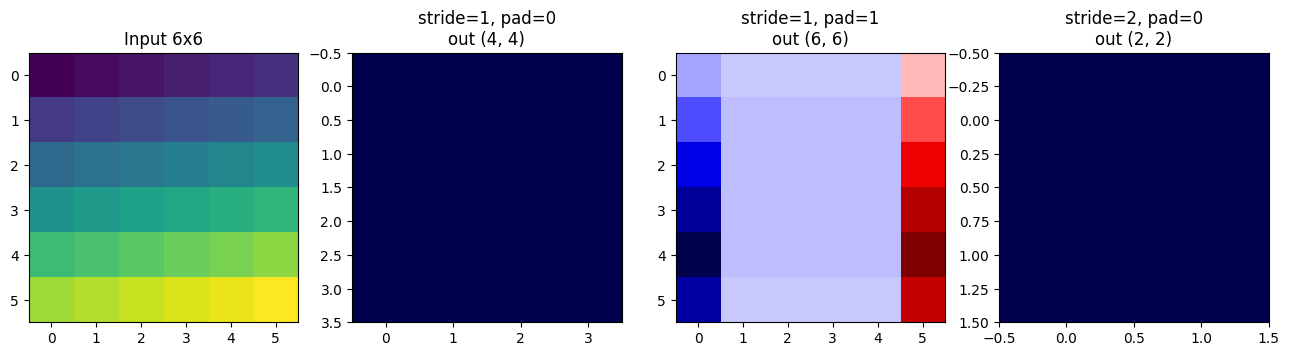

In [7]:
demo()